<a href="https://colab.research.google.com/github/ProfessorPatrickSlatraigh/CIS3120-BMWB/blob/main/storeKeys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Storing and Retrieving Secret/Confidential Variable Content

by Professor Patrick - May-2026  
  
<i>a copy of this notebook is available at [bit.ly/storeKeys](https://bit.ly/storeKeys)  



---



## Why This Matters

An API key is a credential that authenticates a program to a service such as OpenAI, Anthropic, or a database backend. The service treats every request bearing the key as authorized by the key's owner. Exposure of a key is therefore equivalent to handing a stranger a signed blank check.

Exposure happens through any of the following:

- A key written as a literal value inside a notebook cell.
- A key included in cell output, log files, or screen recordings.
- A key committed to a public or private GitHub repository.
- A key shared in a screenshot, screen share, or email.

The principle that follows from this is straightforward: an API key belongs outside the source code. Environment variables are the standard mechanism for keeping a key available to a program without writing the value into the program itself.

This notebook demonstrates the patterns you will use throughout this course and in any program that calls an authenticated web service.

###Four Techniques  
  
This notebook explores the following four techniques for working with API Keys and other secret/confidential values in a Python program.

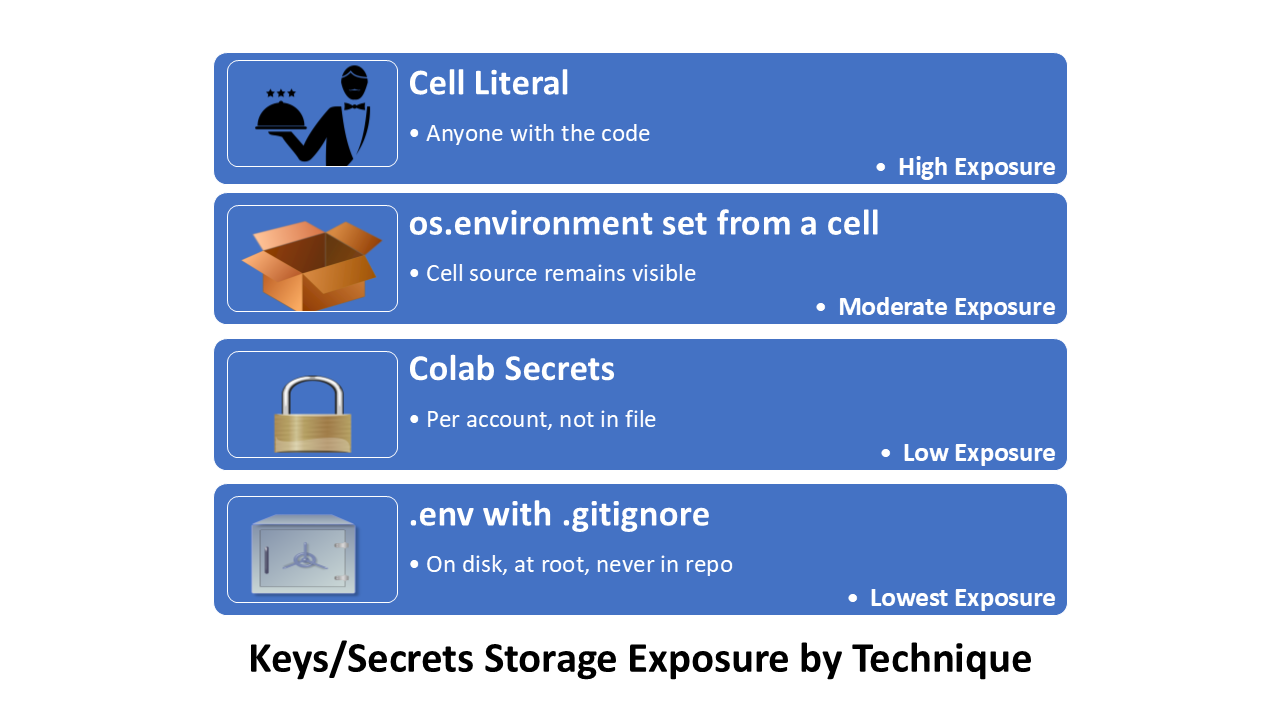



---



## Setup

Every section that follows uses Python's built-in `os` module to read and write operating system environment variables. Run the cell below once before working through the rest of the notebook.

In [ ]:
# Import the os module to work with the operating system environment.
import os



---



## Section 1 — The Recommended Pattern in Colab

When a notebook runs in Google Colab, the safest place to store a key is the Colab Secrets feature. Each Google account has a private secret store that is not part of any notebook file and is not synchronized to GitHub when a notebook is exported. Code running in the notebook can read a secret by name through the `google.colab.userdata` module.

> Before running the cells in this section, open the key icon in the Colab sidebar, add a secret named `MY_API_KEY`, paste your key value into the value field, and grant notebook access to the secret.

### Detecting Colab by import

The standard way to detect whether a notebook is running in Colab is to attempt the Colab-specific import. If the import succeeds, the notebook is in Colab; if it raises `ImportError`, the notebook is running somewhere else. This pattern is more reliable than checking environment variables, because the existence of `google.colab` is the definitive signal.

In [ ]:
try:
    from google.colab import userdata
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f"Running in Colab: {IN_COLAB}")

Running in Colab: True


### Populating the environment variable conditionally

With `IN_COLAB` known, the notebook can populate the operating system environment variable conditionally. When running in Colab, the value comes from Colab Secrets. When running outside Colab, the code assumes that the environment variable was already set by another mechanism (covered in Section 2).

> Note: when running in Colab, the secret named `MY_API_KEY` must exist with a value, or the cell below will raise an exception.

In [ ]:
if IN_COLAB:
    try:
        value = userdata.get("MY_API_KEY")
        if not value or not value.strip():
            print(
                "MY_API_KEY exists in Colab Secrets, but its value is empty. "
                "Open the key icon in the sidebar and paste a non-empty value."
            )
        else:
            os.environ["MY_API_KEY"] = value
            print("Populated environment variable using Google Colab Secrets.")
    except userdata.SecretNotFoundError:
        print(
            "MY_API_KEY does not exist in Colab Secrets. "
            "Open the key icon in the sidebar, add a secret named MY_API_KEY, "
            "and paste your key value into the value field."
        )
    except userdata.NotebookAccessError:
        print(
            "MY_API_KEY exists in Colab Secrets, but this notebook has not "
            "been granted access. Open the key icon in the sidebar and "
            "toggle Notebook access on for MY_API_KEY."
        )
    except userdata.TimeoutException:
        print(
            "Request for MY_API_KEY timed out. "
            "Colab Secrets can only be fetched when running from the Colab UI."
        )
else:
    if os.getenv("MY_API_KEY"):
        print("Relying on a pre-existing operating system environment variable.")
    else:
        print(
            "MY_API_KEY is not set. Set it before continuing, either by "
            "exporting it in your shell or by populating it via getpass."
        )


Populated environment variable using Google Colab Secrets.


### Verifying without exposing

Once the environment variable is set, a program needs to confirm that the value is available before making any authenticated request. The verification must not print the value itself. A simple presence check is sufficient for most purposes.

In [ ]:
my_api_key = os.getenv("MY_API_KEY")
print("MY_API_KEY is set." if my_api_key else "MY_API_KEY is not set.")

MY_API_KEY is set.


For situations where you need to confirm that a particular key is loaded (for example, when switching between multiple environments), display only a fingerprint that consists of the last four characters with the rest masked. This mirrors the format used by Stripe, AWS, and other services in their administrative dashboards.

In [ ]:
if my_api_key:
    masked = "*" * (len(my_api_key) - 4) + my_api_key[-4:]
    print(f"Key fingerprint: {masked}")
else:
    print("MY_API_KEY is not available.")

Key fingerprint: ************rKey




---



## Section 2 — Local Environment Variables

If you later move from Colab to a local Python installation, Colab Secrets is no longer available. The substitute is the operating system's own environment variable mechanism, populated either at the shell level or by a Python program at startup.

### Setting a value safely with getpass

Hardcoding a key as a literal string in a notebook cell contradicts the entire reason environment variables exist, because the literal value would be saved into the .ipynb file and could then travel into version control or shared notebook output. The `getpass` module solves this by prompting for the value at runtime without echoing the input to the screen.

Use `getpass` as a resource for requesting passwords from a user.

In [ ]:
import getpass

# Using getpass to prompt for a key value to store to an environment variable.
# The value will be hidden as it is typed.

os.environ["MY_API_KEY"] = getpass.getpass("Enter MY_API_KEY: ")

Enter MY_API_KEY: ··········


### A note on .env files

In production Python applications outside Colab, the conventional approach is to store environment variables in a file named `.env` at the project root and load them using the `python-dotenv` package. The `.env` file is added to `.gitignore` so that it is never committed to a repository.

A typical `.env` file looks like:

```
MY_API_KEY=actual_key_value_here
OPENAI_API_KEY=another_actual_key_value
```

And the loader pattern is:

```python
from dotenv import load_dotenv
load_dotenv()
my_api_key = os.getenv("MY_API_KEY")
```

This material is mentioned for reference. Assignments in this course use Colab Secrets.

### Retrieving a value

Whether the value was set by `getpass`, by a `.env` file, or by a shell command issued before launching Python, retrieval is identical:

In [ ]:
my_api_key = os.getenv("MY_API_KEY")
print("MY_API_KEY is set." if my_api_key else "MY_API_KEY is not set.")

MY_API_KEY is set.




---



## Section 3 — Alternative Colab Detection (Reference Only)

The primary signal that a notebook is running in Colab is whether `from google.colab import userdata` succeeds. A secondary signal is the presence of Colab-specific environment variables that the Colab virtual machine sets automatically.

> The two most common are `COLAB_RELEASE_TAG` and `COLAB_GPU`. Their existence depends on the configuration of the Colab virtual machine, so neither is guaranteed.

In [ ]:
print(f"COLAB_RELEASE_TAG: {os.getenv('COLAB_RELEASE_TAG')}")
print(f"COLAB_GPU:         {os.getenv('COLAB_GPU')}")

IN_COLAB_BY_ENV = bool(os.getenv("COLAB_RELEASE_TAG") or os.getenv("COLAB_GPU"))
print(f"Detected by environment variable: {IN_COLAB_BY_ENV}")

The import-based detection in Section 1 is preferred because it does not depend on which environment variables a particular Colab runtime has chosen to set.



---



## Section 4 — Connecting the Key to a Real Use

Storage and retrieval are only the setup. The point of an API key is to authenticate a request to a service. The pattern below is what production code looks like once `MY_API_KEY` has been loaded into the environment by either of the methods above.

> The pattern is shown as a comment block rather than executed, so that this notebook can be run end to end without an actual API call. In Module 14 you will replace the comment block with live code.

In [ ]:
api_key = os.getenv("MY_API_KEY")

if api_key is None:
    raise RuntimeError(
        "MY_API_KEY is not set. Halt before making any external call."
    )

# Example pattern — the actual import depends on the service.
#
# For OpenAI:
#
#     from openai import OpenAI
#     client = OpenAI(api_key=api_key)
#     response = client.chat.completions.create(
#         model="gpt-5.5",
#         messages=[{"role": "user", "content": "Hello"}],
#     )
#
# For Anthropic:
#
#     from anthropic import Anthropic
#     client = Anthropic(api_key=api_key)
#     response = client.messages.create(
#         model="claude-opus-4-7",
#         max_tokens=1024,
#         messages=[{"role": "user", "content": "Hello"}],
#     )

print("Key retrieved and ready for use.")



---



## Section 5 — Security Practices Beyond This Notebook

Storing a key in an environment variable removes the most common path to exposure but does not eliminate every risk. Three habits round out the discipline.

### .gitignore for local projects

When working with a local Python project, the `.env` file (or any file containing secrets) must be listed in `.gitignore` before the first commit. Once a secret has been committed, removing it requires both a force-push and treating the key as compromised.

A minimal `.gitignore` for a Python project should include at least:

```
.env
*.env
__pycache__/
.ipynb_checkpoints/
```

### Treat any exposed key as compromised

If a key is ever printed in cell output, committed to a repository, or shared in a screenshot, the correct response is the same: revoke the key in the provider's dashboard and generate a new one. Editing the file or deleting the screenshot does not undo the exposure, because the value may already have been scraped or cached.

### Rotate keys periodically

Most providers allow multiple active keys per account. Rotating keys at regular intervals, or when team members change, limits the damage of a future leak. The rotation procedure is straightforward: generate a new key, update Colab Secrets or the local environment, verify the new key works, then revoke the old key.



---



##Summary  

### Storage location comparison

| Storage location | Value in the .ipynb? | Travels to GitHub? | Reusable from another notebook? | Scope |
|:---|:---:|:---:|:---:|:---|
| Cell literal | Yes | Yes | No | Per notebook |
| `os.environ` set in a cell | Yes | Yes | No | Per notebook |
| Colab Secret | No | No | Yes | Per Google account |
| `.env` file with `.gitignore` | No | No | Yes | Per project |

The first two rows answer identically across every column. That equivalence is the central lesson: wrapping a hardcoded value in `os.environ` does not improve its privacy, because the value is still a literal stored in the notebook source. Only the bottom two rows place the value outside the notebook file, and both of those are reusable from any other notebook that knows the secret name or that loads the same `.env` file.



---

